# Projeto final: previsão de churn

## Fase 1. Análise exploratória (parte 1)

Carregamento da base, tamanho, tipos de dados e sumário estatístico.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = Path("../datasets/ecommerce_dataset.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


### Tamanho da base

In [20]:
n_linhas, n_colunas = df.shape
print(f"Linhas: {n_linhas}")
print(f"Colunas: {n_colunas}")

Linhas: 5630
Colunas: 20


### Tipos de dados

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [22]:
df.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice               str
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode               str
Gender                             str
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                   str
SatisfactionScore                int64
MaritalStatus                      str
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object

### Sumário estatístico

In [23]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


In [24]:
df.describe(include=["object", "string"])

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,3,7,2,6,3
top,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married
freq,2765,2314,3384,2050,2986


## Fase 1. Análise exploratória (parte 2)

Nesta parte, vamos medir o desbalanceamento do alvo, observar a distribuição do tempo de relacionamento e calcular as correlações de Pearson entre as variáveis numéricas.

### Distribuição da variável-alvo

In [25]:
distribuicao_churn = pd.DataFrame(
    {
        "clientes": df["Churn"].value_counts().sort_index(),
        "percentual": df["Churn"].value_counts(normalize=True).sort_index().mul(100),
    }
)
distribuicao_churn.index = ["Permaneceu (0)", "Saiu (1)"]
distribuicao_churn.round(2)

,clientes,percentual
Permaneceu (0),4682,83.16
Saiu (1),948,16.84


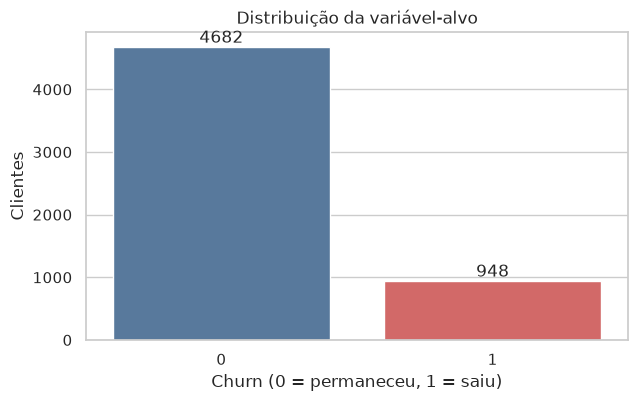

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette={0: "#4C78A8", 1: "#E45756"},
    legend=False,
    ax=ax,
)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set(
    title="Distribuição da variável-alvo",
    xlabel="Churn (0 = permaneceu, 1 = saiu)",
    ylabel="Clientes",
)
plt.show()

### Tempo de relacionamento por classe

In [27]:
df.groupby("Churn")["Tenure"].agg(["count", "mean", "median"]).round(2)

,count,mean,median
Churn,,,
0,4499,11.50,10.0
1,867,3.38,1.0


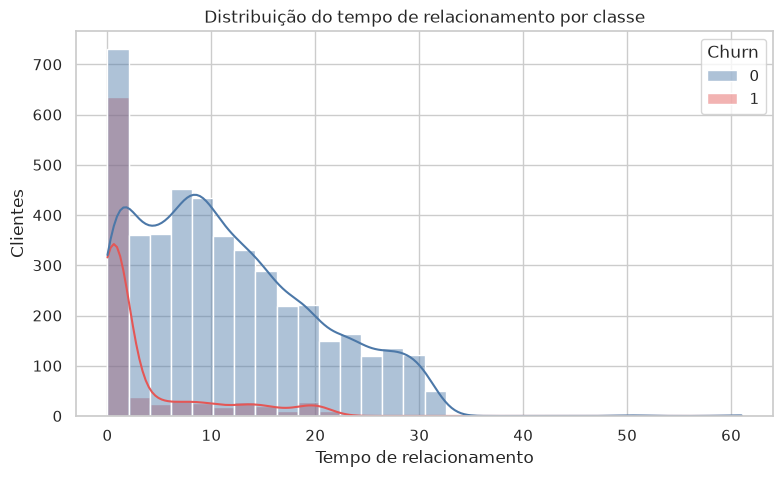

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df,
    x="Tenure",
    hue="Churn",
    bins=30,
    kde=True,
    multiple="layer",
    alpha=0.45,
    palette={0: "#4C78A8", 1: "#E45756"},
    ax=ax,
)
ax.set(
    title="Distribuição do tempo de relacionamento por classe",
    xlabel="Tempo de relacionamento",
    ylabel="Clientes",
)
plt.show()

### Correlação entre variáveis numéricas

`CustomerID` fica fora do cálculo porque é apenas um identificador.

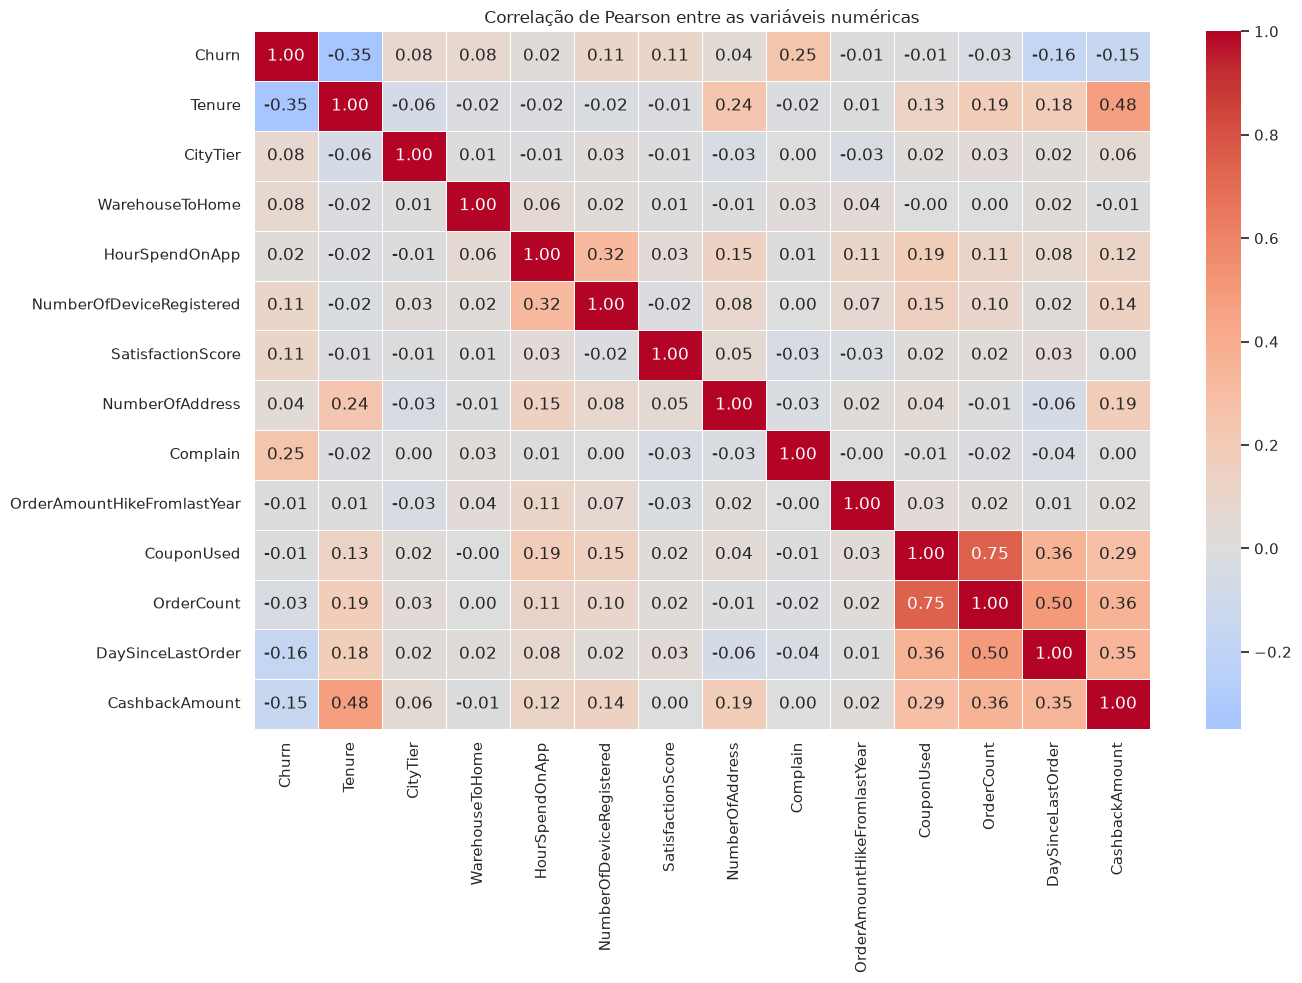

In [29]:
variaveis_numericas = df.select_dtypes(include="number").drop(columns="CustomerID")
correlacao = variaveis_numericas.corr(method="pearson")

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    correlacao,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlação de Pearson entre as variáveis numéricas")
plt.tight_layout()
plt.show()

In [30]:
(
    correlacao["Churn"]
    .drop("Churn")
    .sort_values(key=lambda valores: valores.abs(), ascending=False)
    .head(5)
)

Tenure                     -0.349408
Complain                    0.250188
DaySinceLastOrder          -0.160757
CashbackAmount             -0.154161
NumberOfDeviceRegistered    0.107939
Name: Churn, dtype: float64

### Leitura inicial

A base está desbalanceada: só 16,84% dos clientes saíram. A acurácia sozinha pode passar uma impressão errada.

`Tenure` é o sinal mais forte até agora, com correlação de -0,349. Quem saiu tem mediana 1; quem ficou, 10. Reclamação também puxa o churn, com correlação de 0,250, mas nenhum desses fatores sozinho fecha o caso.

Sete colunas numéricas têm valores ausentes, inclusive `Tenure`. Isso precisa ser resolvido antes da engenharia de atributos e da modelagem. O split vai manter a proporção das classes, e o balanceamento ficará só no treino.

# Fase 2. Limpeza e tratamento

A limpeza começa pelas duplicatas e pelos valores ausentes. Depois, usamos boxplots e o intervalo interquartil para entender os extremos antes de decidir se vale alterar algum registro.

## Registros duplicados

In [31]:
quantidade_duplicadas = int(df.duplicated().sum())
print(f"Linhas duplicadas: {quantidade_duplicadas}")

df_limpo = df.drop_duplicates().copy()
print(f"Formato após a remoção: {df_limpo.shape}")

Linhas duplicadas: 0
Formato após a remoção: (5630, 20)


A busca não encontrou duplicatas. Ainda assim, mantemos `drop_duplicates()` no fluxo para que a limpeza continue válida se a fonte mudar.

## Valores ausentes

Vamos comparar quantidade de nulos, assimetria, média e mediana. Quanto mais distante de zero estiver a assimetria, menos a média representa o centro da distribuição.

In [32]:
nulos_por_coluna = df_limpo.isna().sum()
colunas_com_nulos = nulos_por_coluna[nulos_por_coluna > 0].index.tolist()

resumo_nulos = pd.DataFrame(
    {
        "ausentes": nulos_por_coluna[colunas_com_nulos],
        "percentual": nulos_por_coluna[colunas_com_nulos].div(len(df_limpo)).mul(100),
        "assimetria": df_limpo[colunas_com_nulos].skew(),
        "media": df_limpo[colunas_com_nulos].mean(),
        "mediana": df_limpo[colunas_com_nulos].median(),
    }
).sort_values("ausentes", ascending=False)

resumo_nulos.round(2)

,ausentes,percentual,assimetria,media,mediana
DaySinceLastOrder,307,5.45,1.19,4.54,3.0
OrderAmountHikeFromlastYear,265,4.71,0.79,15.71,15.0
Tenure,264,4.69,0.74,10.19,9.0
OrderCount,258,4.58,2.20,3.01,2.0
CouponUsed,256,4.55,2.55,1.75,1.0
HourSpendOnApp,255,4.53,-0.03,2.93,3.0
WarehouseToHome,251,4.46,1.62,15.64,14.0


`HourSpendOnApp` é praticamente simétrica, com assimetria de -0,03, então vamos preencher seus nulos com a média. As outras seis colunas têm cauda à direita e valores extremos. Nelas, a mediana é uma escolha mais segura e muda menos com esses extremos.

In [33]:
estrategias_imputacao = {
    "Tenure": "mediana",
    "WarehouseToHome": "mediana",
    "HourSpendOnApp": "media",
    "OrderAmountHikeFromlastYear": "mediana",
    "CouponUsed": "mediana",
    "OrderCount": "mediana",
    "DaySinceLastOrder": "mediana",
}

registro_imputacao = []

for coluna, estrategia in estrategias_imputacao.items():
    if estrategia == "media":
        valor = df_limpo[coluna].mean()
    else:
        valor = df_limpo[coluna].median()

    df_limpo[coluna] = df_limpo[coluna].fillna(valor)
    registro_imputacao.append(
        {"coluna": coluna, "estrategia": estrategia, "valor": valor}
    )

pd.DataFrame(registro_imputacao).round({"valor": 2})

,coluna,estrategia,valor
0,Tenure,mediana,9.00
1,WarehouseToHome,mediana,14.00
2,HourSpendOnApp,media,2.93
3,OrderAmountHikeFromlastYear,mediana,15.00
4,CouponUsed,mediana,1.00
5,OrderCount,mediana,2.00
6,DaySinceLastOrder,mediana,3.00


In [34]:
print(f"Valores ausentes após a imputação: {int(df_limpo.isna().sum().sum())}")

Valores ausentes após a imputação: 0


## Outliers

O boxplot ajuda a localizar valores distantes do miolo da distribuição. Para contar esses pontos, usamos a regra de 1,5 vezes o intervalo interquartil.

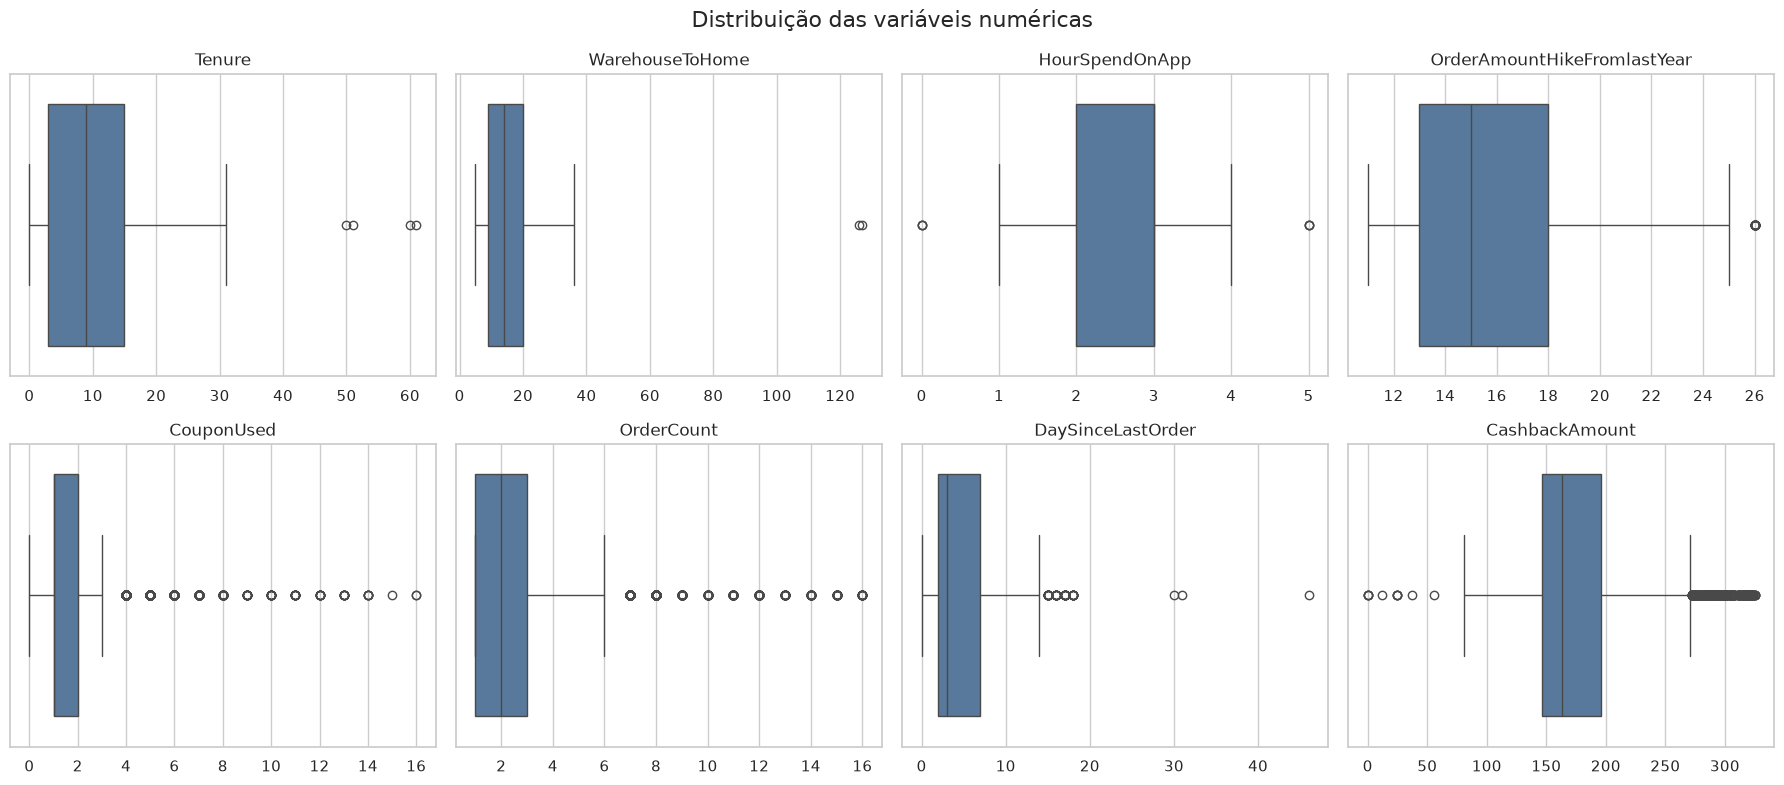

In [35]:
colunas_para_boxplot = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
]

fig, eixos = plt.subplots(2, 4, figsize=(18, 8))

for coluna, eixo in zip(colunas_para_boxplot, eixos.flat):
    sns.boxplot(x=df_limpo[coluna], color="#4C78A8", ax=eixo)
    eixo.set_title(coluna)
    eixo.set_xlabel("")

fig.suptitle("Distribuição das variáveis numéricas", fontsize=16)
plt.tight_layout()
plt.show()

In [36]:
registro_outliers = []

for coluna in colunas_para_boxplot:
    primeiro_quartil = df_limpo[coluna].quantile(0.25)
    terceiro_quartil = df_limpo[coluna].quantile(0.75)
    intervalo_interquartil = terceiro_quartil - primeiro_quartil
    limite_inferior = primeiro_quartil - 1.5 * intervalo_interquartil
    limite_superior = terceiro_quartil + 1.5 * intervalo_interquartil
    fora_dos_limites = (
        (df_limpo[coluna] < limite_inferior)
        | (df_limpo[coluna] > limite_superior)
    )
    quantidade = int(fora_dos_limites.sum())

    registro_outliers.append(
        {
            "coluna": coluna,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "outliers": quantidade,
            "percentual": quantidade / len(df_limpo) * 100,
        }
    )

resumo_outliers = pd.DataFrame(registro_outliers).sort_values(
    "percentual", ascending=False
)
resumo_outliers.round(2)

,coluna,limite_inferior,limite_superior,outliers,percentual
5,OrderCount,-2.0,6.0,703,12.49
4,CouponUsed,-0.5,3.5,629,11.17
7,CashbackAmount,71.0,271.0,447,7.94
6,DaySinceLastOrder,-5.5,14.5,62,1.10
3,OrderAmountHikeFromlastYear,5.5,25.5,33,0.59
2,HourSpendOnApp,0.5,4.5,6,0.11
0,Tenure,-15.0,33.0,4,0.07
1,WarehouseToHome,-7.5,36.5,2,0.04


### Decisão sobre os outliers

Vamos manter os valores. A regra do IQR marcou 12,49% de `OrderCount` e 11,17% de `CouponUsed`, mas são contagens plausíveis de clientes mais ativos. Cortá-las apagaria justamente parte do comportamento que queremos estudar. Os extremos das outras colunas também não bastam, sozinhos, para afirmar que houve erro de cadastro.

Essa escolha exige cuidado com o KNN, porque distâncias grandes pesam no resultado. Na etapa de modelagem, o escalonamento será ajustado apenas no treino e vamos comparar as métricas de treino e teste. A Árvore de Decisão é menos sensível a esses extremos.

## Resultado da limpeza

Não havia duplicatas para remover. Os nulos foram preenchidos com média em `HourSpendOnApp` e mediana nas outras seis colunas. Os outliers foram mantidos porque parecem representar comportamento real, não erro confirmado.

In [37]:
pd.Series(
    {
        "linhas": len(df_limpo),
        "colunas": df_limpo.shape[1],
        "duplicatas": int(df_limpo.duplicated().sum()),
        "valores_ausentes": int(df_limpo.isna().sum().sum()),
    },
    name="resultado",
)

linhas              5630
colunas               20
duplicatas             0
valores_ausentes       0
Name: resultado, dtype: int64